In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [2]:
df = pd.read_csv("../data/ia_nwa_content_comparison_date_filtered.csv").sort_values(
    "both", ascending=False
)
df.head(20)

,newsgroup,ia_only,nwa_only,both
187,no.marked.data,26961,21026,1075
114,no.general,75058,75170,1000
12,no.alt.flame,14972,18762,982
184,no.marked,18179,24942,750
249,no.slekt,4355,7520,585
214,no.pc,30474,24811,499
196,no.musikk,22380,26875,449
228,no.religion,23371,19923,392
181,no.mac,17334,21583,300
91,no.film,9066,12162,244


In [3]:
ia_only = df["ia_only"].sum()
nwa_only = df["nwa_only"].sum()
both = df["both"].sum()

print(f"IA only:  {ia_only:,}")
print(f"NWA only: {nwa_only:,}")
print(f"Both:     {both:,}")

IA only:  558,134
NWA only: 595,974
Both:     8,976


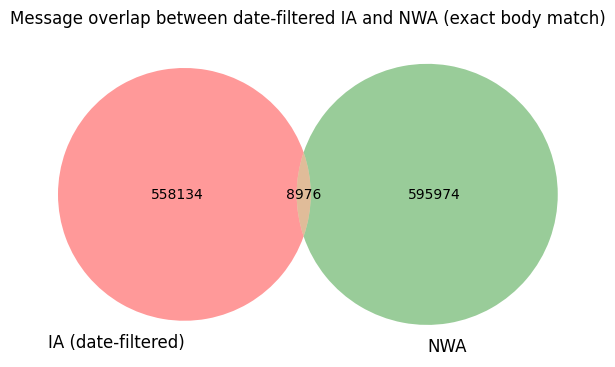

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
venn2(
    subsets=(ia_only, nwa_only, both),
    set_labels=("IA (date-filtered)", "NWA"),
    ax=ax,
)
ax.set_title("Message overlap between date-filtered IA and NWA (exact body match)")
plt.tight_layout()
plt.show()

In [5]:
sum_i = (df.nwa_only + df.ia_only).sort_values(ascending=False).index
sortby_sum = df.loc[sum_i]
sortby_sum = sortby_sum[(sortby_sum.nwa_only > 1) & (sortby_sum.ia_only > 1)]
top_50_sum = sortby_sum.head(50)
top_50_sum.to_json(
    "../data/newsgroups_for_selection.jsonl", index=False, lines=True, orient="records"
)